In [49]:
import pickle
import igraph as ig

with open("graphs/real/FINDER/Crime.pkl",'rb') as f:
    g = pickle.load(f) 

print(g.summary())

IGRAPH U--- 829 1473 -- 
+ attr: _nx_name (v)


community detection/ partition methods

centrality
- Degree
- Betweenness
- Pagerank
- CI

In [50]:
'''centrality '''
from copy import deepcopy
from typing import Callable
import igraph as ig
import random

def Degree(g:ig.Graph,k:int):
    '''
    return the nodes with top-k highest degree in a graph
    '''
    # handle invalid 
    if k==0: k = 1
    k = int(k)  # ensure k is integer
    
    # get all nodes and their degrees
    degrees = [(node, g.degree(node)) for node in range(g.vcount())]
    
    # sort by degree in descending order and get top k
    degrees.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, degree in degrees[:k]]

def Betweenness(g:ig.Graph, k:int):
    '''
    Return the nodes with top-k highest betweenness centrality in a graph
    '''
    # handle invalid 
    if k==0: k = 1
    k = int(k)  # ensure k is integer

    # calculate betweenness centrality for all nodes at once (more efficient)
    betweenness_scores = g.betweenness()
    
    # create list of (node, betweenness_score) tuples
    scores = [(node, betweenness_scores[node]) for node in range(g.vcount())]
    
    # sort by degree in descending order and get top k
    scores.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, score in scores[:k]]

def PageRank(g:ig.Graph, k:int):
    '''
    Return the nodes with top-k highest PageRank scores in a graph
    '''
    # handle invalid
    if k == 0: k = 1
    k = int(k)  # ensure k is integer
    
    # calculate PageRank scores for all nodes
    pagerank_scores = g.pagerank()
    
    # create list of (node, pagerank_score) tuples
    scores = [(node, pagerank_scores[node]) for node in range(g.vcount())]
    
    # sort by PageRank score in descending order and get top k
    scores.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, score in scores[:k]]


def CollectiveInfluence(g:ig.Graph, k:int, radius:int=2):
    '''
    Return the nodes with top-k highest Collective Influence (CI) in a graph
    CI(i) = (k_i - 1) * sum((k_j - 1) for j in neighbors at distance radius)
    
    Args:
        g: igraph Graph object
        k: number of top nodes to return
        radius: distance for calculating collective influence (default=2)
    '''
    # handle invalid
    if k == 0: k = 1
    k = int(k)  # ensure k is integer
    
    ci_scores = []
    
    for node in range(g.vcount()):
        # degree of current node
        k_i = g.degree(node)
        
        if k_i == 0:
            ci_scores.append((node, 0))
            continue
        
        # find neighbors at distance 'radius'
        # get shortest paths from node to all other nodes
        distances = g.shortest_paths(source=node)[0]
        
        # sum of (degree - 1) for all nodes at distance 'radius'
        ci_sum = sum(g.degree(j) - 1 for j in range(g.vcount()) 
                     if distances[j] == radius)
        
        # CI(i) = (k_i - 1) * sum
        ci = (k_i - 1) * ci_sum
        ci_scores.append((node, ci))
    
    # sort by CI score in descending order and get top k
    ci_scores.sort(key=lambda x: x[1], reverse=True)
    
    # return the node indices of top k nodes
    return [node for node, score in ci_scores[:k]]

def CentralityAdaptive(g:ig.Graph,centrality:Callable,step_ratio=None,max_iterations=None,**kwargs):
    '''
    centrality: optional[Degree,Betweenness,PageRank,CollectiveInfluence]
    return the centrality based node list using static_id attribute to track original IDs
    '''
    if step_ratio == None: 
        step_ratio = 1/g.vcount()
    if max_iterations is None:
        max_iterations = 1/step_ratio

    g_copy = deepcopy(g)    
    # Add static_id attribute to track original node IDs
    g_copy.vs['static_id'] = list(range(g.vcount()))
    iteration = 0
    result = []

    while g_copy.vcount() > 0 and g_copy.ecount() > 0 and iteration < max_iterations:
        # calculate how many nodes to remove
        k = max(1, int(g_copy.vcount() * step_ratio))
        
        # get top k nodes from current graph
        cur_node_list = centrality(g_copy, k, **kwargs)
        
        # map back to original node IDs using static_id attribute
        original_node_ids = [g_copy.vs[node]['static_id'] for node in cur_node_list]
        result.extend(original_node_ids)
        
        # remove nodes from graph copy (static_id is automatically maintained for remaining nodes)
        g_copy.delete_vertices(cur_node_list)
        iteration += 1
    return result


# Test the centrality functions
print("Testing centrality methods...")
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
print(f"Degrees: {g_test.degree()}")

random.seed(0)
g_test = ig.Graph.Erdos_Renyi(n=10, p=0.2)
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
print("\nTesting CentralityAdaptive with different methods...")
print(f"Adaptive Degree centrality result: {CentralityAdaptive(g_test, Degree, step_ratio=0.3)}")
print(f"Adaptive Betweenness centrality result: {CentralityAdaptive(g_test, Betweenness, step_ratio=0.3)}")
print(f"Adaptive PageRank centrality result: {CentralityAdaptive(g_test, PageRank, step_ratio=0.3)}")
print(f"Adaptive CI centrality result: {CentralityAdaptive(g_test, CollectiveInfluence, step_ratio=0.3,radius = 3)}")


Testing centrality methods...
Test graph: 5 nodes, 6 edges
Degrees: [3, 2, 2, 3, 2]
Test graph: 10 nodes, 13 edges

Testing CentralityAdaptive with different methods...
Adaptive Degree centrality result: [2, 0, 1, 5, 3, 4]
Adaptive Betweenness centrality result: [1, 2, 4, 7, 0, 3]
Adaptive PageRank centrality result: [2, 1, 4, 5, 0]
Adaptive CI centrality result: [1, 0, 3, 2, 4, 5]


C:\Users\Rich\AppData\Local\Temp\ipykernel_18376\4100059775.py:91: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  distances = g.shortest_paths(source=node)[0]


## MultiStage dismantling

### Stage 1: Preprocess


In [70]:
import importlib
import utils
importlib.reload(utils.community_detection)
from utils.community_detection import COMMUNITY_METHODS,partition

# test clustering
clustering = partition(g,partition_method='lcd', threshold=0.05)

print(f"Found {len(clustering)} communities")
for i in range(min(3, len(clustering))):  # Show first 3
    print(f"Community {i}: {clustering[i]}")

Found 55 communities
Community 0: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 57, 58, 59, 68, 69, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 107, 132, 133, 134, 136, 137, 166, 179, 180, 181, 182, 183, 200, 201, 220, 230, 244, 245, 247]
Community 1: [258, 133, 10, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 39, 40, 41, 42, 43, 44, 45, 166, 167, 409, 180, 185, 318, 194, 395, 271, 94, 273, 351, 223, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 490, 367, 114, 371, 372, 376]
Community 2: [128, 386, 131, 134, 392, 14, 30, 161, 36, 58, 166, 55, 56, 184, 186, 187, 188, 189, 190, 60, 64, 65, 66, 61, 62, 63, 192, 193, 194, 195, 196, 197, 198, 1

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

def get_lcc_size(graph):
    """Get the size of the largest connected component"""
    if graph.vcount() == 0:
        return 0
    components = graph.connected_components()
    return max(components.sizes())


def preprocess(graph, centrality=None, centrality_config ={}, partition_method=None, partition_config = {}, max_iterations=None):
    """
    Multi-layer network dismantling baseline
    
    Strategy:
    1. Find the largest connected component (LCC)
    2. Apply community detection on the LCC
    3. Select top node from each community using specified centrality measure
    4. Remove these nodes from the ENTIRE graph (not just LCC)
    
    Args:
        graph: igraph Graph object
        centrality: centrality function to use (default: Degree)
        max_iterations: maximum number of iterations (layers)
        partition_method: community detection method (default: 'fast_greedy')
        **kwargs: additional arguments to pass to centrality function
    
    Returns:
        removed_nodes: list of removed node 
        remove_sizes: removed node number sum after each iteration
        lcc_sizes: list of LCC sizes at each iteration
    """
    if centrality is None:
        centrality = Degree
    
    if partition_method is None:
        partition_method = 'fast_greedy'
    
    g = deepcopy(graph)
    # Add static_id attribute to track original node IDs
    g.vs['static_id'] = list(range(g.vcount()))
    
    removed_nodes = set()
    removed_sizes = [0]
    lcc_sizes = []
    
    iteration = 0
    if max_iterations is None:
        max_iterations = g.vcount()
    
    while g.vcount() > 0 and g.ecount() > 0 and iteration < max_iterations:
        # Step 1: Get the largest connected component (LCC)
        components = g.connected_components()
        lcc_indices = max(components, key=len)  # Node indices in LCC
        lcc_sizes.append(len(lcc_indices))
        
        # If LCC is too small, stop
        if len(lcc_indices) == 0:
            break
        
        # Step 2: Extract LCC as a subgraph
        lcc_subgraph = g.subgraph(lcc_indices)
        
        # Step 3: Apply community_fastgreedy on the LCC
        # Use the community_detection function
        clustering = partition(lcc_subgraph,partition_method=partition_method, **partition_config)
        
        # Step 4: Find the most important node in each community using degree heuristic
        nodes_to_remove = set()

        for i in range(len(clustering)):
            comm_nodes = clustering[i]
            if comm_nodes:
                # Create a subgraph of just this community to apply centrality
                comm_subgraph = lcc_subgraph.subgraph(comm_nodes)
                
                # Use the provided centrality method to find best node in this community
                best_nodes_in_comm = centrality(comm_subgraph, k=1, **centrality_config)
                
                if best_nodes_in_comm:
                    best_node_in_comm_subgraph = best_nodes_in_comm[0]

                    # Map from community subgraph index -> LCC subgraph index -> current graph index
                    current_graph_node_id = lcc_indices[comm_nodes[best_node_in_comm_subgraph]]
                    
                    # Use static_id to get the true original node ID
                    if 'static_id' in g.vs.attributes():
                        original_node_id = g.vs[current_graph_node_id]['static_id']
                    else:
                        original_node_id = current_graph_node_id
                    
                    nodes_to_remove.add(current_graph_node_id)
                    removed_nodes.add(original_node_id)
        


        # Step 5: Remove the K best nodes from the ENTIRE graph
        if nodes_to_remove:
            g.delete_vertices(nodes_to_remove)
            # removed_nodes.extend(nodes_to_remove)
            removed_sizes.append(removed_sizes[-1]+len(nodes_to_remove))
        else:
            break
        
        iteration += 1
    
    lcc_sizes.append(get_lcc_size(g))
    
    return g, removed_nodes, removed_sizes, lcc_sizes

print("Testing process methods...")
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
preprocess(g_test, 
           partition_method = 'fast_greedy',
           partition_config = {'K':2},
           max_iterations=2)

Testing process methods...


(<igraph.Graph at 0x27d6fd46b40>, {0, 1, 2, 4}, [0, 2, 4], [5, 3, 1])

In [55]:
# Run the Preprocess algorithm
print(f"Original graph: {g.vcount()} nodes, {g.ecount()} edges")
print("Running Preprocessing...")

# Test with Degree centrality
g_process, removed_nodes, removed_sizes, lcc_sizes = preprocess(
    g,centrality=Degree, max_iterations=2, partition_method='fast_greedy',partition_config={'K':15}
)

assert (len(removed_sizes) == len(lcc_sizes))
print(f"\nPreprocess completed in {len(removed_sizes)-1} iterations")
assert (len(removed_nodes) == removed_sizes[-1])
print(f"Total nodes removed: {len(removed_nodes)}")
print(f"Remaining nodes: {g_process.vcount()}")
print(f"Remaining edges: {g_process.ecount()}")

Original graph: 829 nodes, 1473 edges
Running Preprocessing...

Preprocess completed in 2 iterations
Total nodes removed: 30
Remaining nodes: 799
Remaining edges: 1106


In [ ]:
removed_nodes[:10], len(removed_nodes)

{1,
 14,
 43,
 67,
 75,
 94,
 105,
 107,
 115,
 121,
 167,
 170,
 191,
 193,
 194,
 197,
 212,
 216,
 229,
 242,
 256,
 282,
 287,
 313,
 333,
 363,
 418,
 523,
 534,
 605}

### Stage 2: Dismantling

In [57]:
# COPY from MIND_ND/validate.py and test_single.py
def MIND(graph,step_ratio=None,ckpt_pth='saved/mind.ckpt'):
    from networks.dismantle import SACPolicy
    import torch
    from copy import deepcopy
    from scipy.integrate import simpson
    from utils.graph_data import Batch, ig_to_data

    device: str='cuda:0'
    # device = torch.device('cpu')
    # Load policy
    sac = SACPolicy(
        num_features=16,
        num_heads=4,
        num_mps=6,
    ).to(device)
    sac.load_state_dict(torch.load(ckpt_pth)['policy_state_dict'])
    policy = sac

    # Make a copy and initialize tracking
    g = deepcopy(graph)
    n_init = g.vcount()
    g.vs["i_init"] = list(range(n_init))
    
    policy.eval()

    gcc_eps = []  # LCC size/n_init at each step, note: the start 1 is ignored
    lcc_sizes = [g.connected_components().giant().vcount()]  # LCC size at each step,start from 
    removals = []  # Removed node IDs (original)
    

    # Calculate step size
    if step_ratio is not None and step_ratio > 0:
        step_size = max(int(step_ratio * n_init), 1)
    else:
        step_size = 1

    # Main dismantling loop
    finished = False
    while not finished:
        # Get action probabilities from policy
        with torch.no_grad():
            batch_data = Batch(device, [ig_to_data(g)])
            _, log_probs = policy.get_action(batch_data, val=True)
        
        # Convert to probabilities and get top-k nodes
        probs = log_probs.exp().cpu().numpy()
        
        # Select top step_size nodes based on probabilities
        current_step = min(step_size, len(probs))
        top_k_indices = np.argsort(-probs)[:current_step]
        
        # Remove nodes sequentially
        for idx in sorted(top_k_indices, reverse=True):  # Remove in reverse order to avoid index shifts
            if idx < g.vcount():  # Safety check
                original_id = g.vs[idx]["i_init"]
                removals.append(original_id)
                g.delete_vertices(idx)
                # Check termination condition
                lcc_size = g.connected_components().giant().vcount()
                lcc_sizes.append(lcc_size)
                gcc_eps.append(lcc_size / n_init)
                if lcc_size / n_init < 0.1 or g.ecount() == 0:
                    finished = True
                    break
    
    # Calculate metrics
    auc = simpson(gcc_eps, dx=1)
    robustness = sum(gcc_eps[::-1][:-1]) / n_init
    
    return auc, robustness, gcc_eps, lcc_sizes, removals,step_size


In [58]:
# COPY from /code/testReal.py
def FINDER(graph,step_ratio=None,model_path='FINDER/models/graphSage_BA_nrange_30_50_m_4'):
    import sys
    import os
    FINDER_dir = "O:\My_Codes\GD2026\AAA-NetDQN\code"
    FINDER_type = model_path.split("/")[0]
    sys.path.append(FINDER_dir)
    sys.path.append(os.path.join(FINDER_dir,f'{FINDER_type}'))
    print(sys.path)
    if "moe" in FINDER_type:
        sys.path.append(os.path.join(FINDER_dir,'FINDER'))
        from GraphDQN import GraphDQN
        from MoEGraphDQN import MoEGraphDQN
        DQN_cls = MoEGraphDQN
    elif "advance" in FINDER_type:
        from AdvanceGraphDQN import AdvanceGraphDQN
        DQN_cls = AdvanceGraphDQN
    else:
        from GraphDQN import GraphDQN
        DQN_cls = GraphDQN
    
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
# FINDER(g_test)


In [59]:
from typing import Callable,Dict
import numpy as np
  
def dismantling(g:ig.Graph,dismantling_method,**kwargs):
    '''
    same return with preprocess
    removed_nodes: complete solution
    removed_sizes: cumulative removed number at each step, start from 0
    lcc_sizes: lcc size at each step, len(lcc_sizes) = len(removed_sizes)
    '''
    g = deepcopy(g)

    # Implementation
    if dismantling_method is None:
        dismantling_method = CentralityAdaptive
        #TODO defalut kwargs


    # If using CentralityAdaptive, pass the centrality and step_ratio
    if dismantling_method == CentralityAdaptive:
        result = dismantling_method(g, **kwargs)

    # elif dismantling_method == FINDER:
    #     result = dismantling_method(g, **kwargs)
        
    elif dismantling_method == MIND:
        auc, robustness, _, lcc_sizes, removals, step_size = dismantling_method(g, **kwargs)
        # construct the return
        removed_nodes = removals
        removed_sizes = np.arange(0,len(removals),step_size).tolist()
        if removed_sizes[-1] != len(removals):
            removed_sizes.append(len(removals))
        lcc_sizes = [lcc_sizes[n] for n in removed_sizes]
    
    #map static id to result if static_id is provided
    for i,node_id in enumerate(removed_nodes):
        # Use static_id to get the true original node ID
        if 'static_id' in g.vs.attributes():
            original_node_id = g.vs[node_id]['static_id']
        else:
            original_node_id = node_id
        removed_nodes[i] = original_node_id
    
    return auc, robustness, removed_nodes, removed_sizes, lcc_sizes

# Test the dismantling functions
print("Testing dismantling methods...")
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
_, _, test_removed_nodes, test_removed_sizes, test_lcc_sizes = dismantling(g_test,MIND,step_ratio=0.0025)
assert len(test_removed_sizes)==len(test_lcc_sizes)
# dismantling(g_test,MIND,step_ratio=0.4)

Testing dismantling methods...
Test graph: 5 nodes, 6 edges


In [60]:
_, _, new_removed_nodes, new_removed_sizes, new_lcc_sizes = dismantling(g_process,MIND,step_ratio=0.025)

print(f"Original graph: {g.vcount()} nodes, {g.ecount()} edges")
print("------------  Preprocess output: ------------------")
print("removed_sizes: ",removed_sizes)
print("lcc sizes: ",lcc_sizes)

print("\n----------- Dismantling output: -------------------")
print("new_removed_sizes: ",new_removed_sizes)
print("new_lcc_sizes: ",new_lcc_sizes)

set(new_removed_nodes) & set(removed_nodes)  #assumed to be empty set

Original graph: 829 nodes, 1473 edges
------------  Preprocess output: ------------------
removed_sizes:  [0, 15, 30]
lcc sizes:  [829, 781, 735]

----------- Dismantling output: -------------------
new_removed_sizes:  [0, 19, 38, 57, 76, 95, 97]
new_lcc_sizes:  [735, 650, 564, 479, 402, 104, 72]


set()

In [ ]:
new_removed_nodes[:10], len(new_removed_nodes)

[727,
 704,
 527,
 437,
 417,
 416,
 386,
 344,
 280,
 249,
 188,
 169,
 131,
 122,
 58,
 52,
 42,
 32,
 19,
 469,
 385,
 377,
 374,
 306,
 260,
 255,
 243,
 226,
 184,
 159,
 139,
 136,
 135,
 117,
 106,
 45,
 35,
 24,
 587,
 569,
 512,
 508,
 489,
 470,
 379,
 375,
 369,
 299,
 290,
 228,
 206,
 202,
 138,
 93,
 83,
 41,
 30,
 722,
 600,
 568,
 535,
 397,
 332,
 328,
 276,
 261,
 259,
 246,
 189,
 172,
 166,
 101,
 76,
 70,
 37,
 17,
 791,
 646,
 585,
 573,
 453,
 430,
 392,
 370,
 331,
 289,
 264,
 258,
 224,
 205,
 173,
 123,
 91,
 86,
 74,
 685,
 645]

### 3. Plot the 2-Stage  

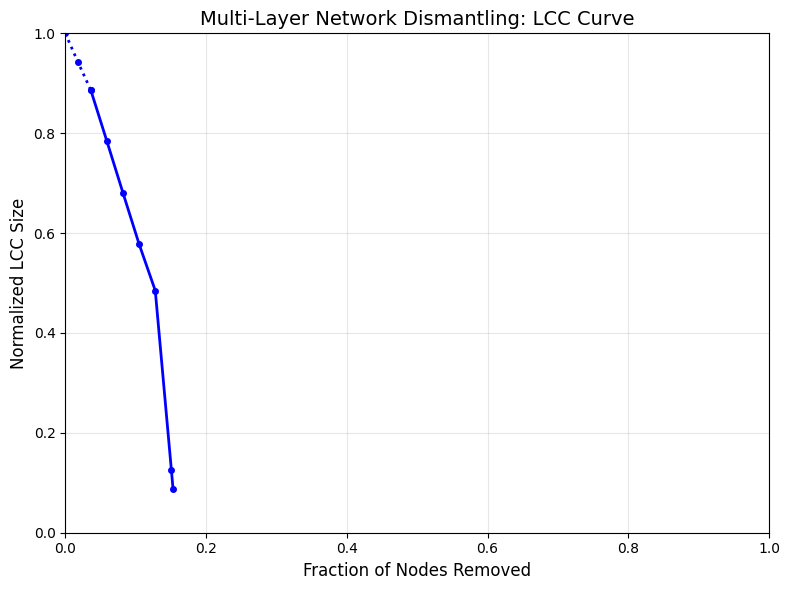


Key Statistics:
Original LCC size: 829 (0.00%)
Final LCC size: 72 (8.69%)


In [62]:
import numpy as np

plt.figure(figsize=(8, 6))
n_init = g.vcount()

# Plot the LCC curve in 1.preprocess
x = np.array(removed_sizes) / n_init
y = np.array(lcc_sizes) / n_init
plt.plot(x, y, 'b:', linewidth=2, marker='o', markersize=4)

# Plot the LCC curve in 2.dismantling
pro_removed_size = removed_sizes[-1]
new_x =(np.array(new_removed_sizes) + pro_removed_size) / n_init
new_y = np.array(new_lcc_sizes) / n_init
plt.plot(new_x, new_y, 'b-', linewidth=2, marker='o', markersize=4)


plt.xlabel('Fraction of Nodes Removed', fontsize=12)
plt.ylabel('Normalized LCC Size', fontsize=12)
plt.title('Multi-Layer Network Dismantling: LCC Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print(f"\nKey Statistics:")
print(f"Original LCC size: {lcc_sizes[0]} ({x[0]:.2%})")
print(f"Final LCC size: {new_lcc_sizes[-1]} ({new_y[-1]:.2%})")

## comprehensive analysis

### comprehensive analysis baseline

load graph from graphs/real/FINDER/Crime.pkl,829 nodes, 1473 nodes


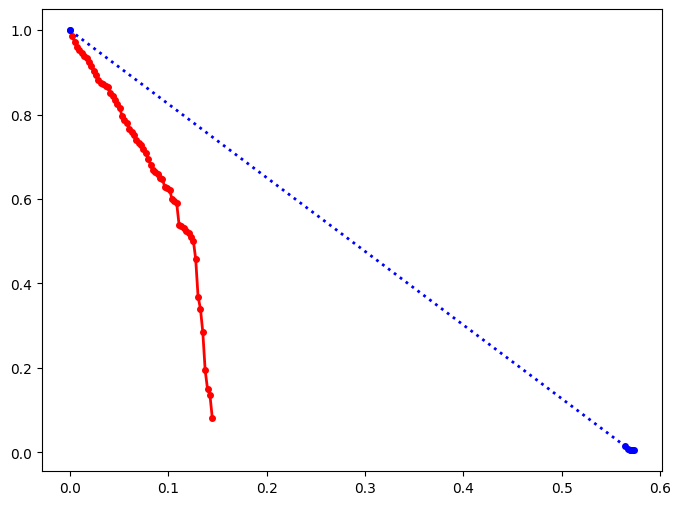

In [66]:
from dataclasses import dataclass, asdict
from typing import Callable,Dict,Optional

@dataclass
class partitionConfig:
    K: int = Optional

@dataclass
class Config:
    g_path: str = "graphs/real/FINDER/Crime.pkl"
    step_ratio: float = 0.0025
    # baselines: List[Callable] = [MIND, CentralityAdaptive]

    Is_Preprocess: bool = False
    partition_method: Callable = None
    partition_config: partitionConfig = None
    centrality: Callable = None
    centrality_config = {}
    max_iterations: int = 1 

    dismantling_method:Callable = MIND


def comprehensive_baseline(config:Config):
    # load g
    with open(config.g_path,'rb') as f:
        g = pickle.load(f) 
    print(f"load graph from {config.g_path},{g.vcount()} nodes, {g.ecount()} nodes")
    plt.figure(figsize=(8, 6))
    n_init = g.vcount()

    # dismantling baseline
    auc, robustness, removed_nodes, removed_sizes, lcc_sizes = dismantling(
        g,
        MIND,
        step_ratio = config.step_ratio
    )
    x = np.array(removed_sizes) / n_init
    y = np.array(lcc_sizes) / n_init
    plt.plot(x, y, 'r-', linewidth=2, marker='o', markersize=4)

    # MultiStage dismantling
    if config.Is_Preprocess:
        g_process, removed_nodes, removed_sizes, lcc_sizes = preprocess(
            g,  
            centrality = config.centrality,
            max_iterations = config.max_iterations, 
            partition_method = config.partition_method,
            partition_config = config.partition_config
        )

        auc, robustness, new_removed_nodes, new_removed_sizes, new_lcc_sizes = dismantling(
            g_process,
            config.dismantling_method,
            step_ratio = config.step_ratio
        )
        
        # Plot the LCC curve in 1.preprocess
        x = np.array(removed_sizes) / n_init
        y = np.array(lcc_sizes) / n_init
        plt.plot(x, y, 'b:', linewidth=2, marker='o', markersize=4)

        # Plot the LCC curve in 2.dismantling
        pro_removed_size = removed_sizes[-1]
        new_x =(np.array(new_removed_sizes) + pro_removed_size) / n_init
        new_y = np.array(new_lcc_sizes) / n_init
        plt.plot(new_x, new_y, 'b-', linewidth=2, marker='o', markersize=4)


config=Config(
    g_path = "graphs/real/FINDER/Crime.pkl",
    dismantling_method=MIND,
    step_ratio = 0.0025,
    Is_Preprocess = True,
    partition_method = 'lcd',
    partition_config = {
                        'K':5,
                        'threshold': 0.7
                        },
    centrality = PageRank,
    max_iterations = 5 
)

# {**asdict(config)}
config.partition_config

comprehensive_baseline(config)

## Is Stage 1 useful?

how to choose community detection, centrality, K (community num), max_iterations?

### 1: community detection analysis


## Which dismantling method in Stage 2 is better?

In [64]:
### 1